# Deep Dive into Customer Demographics and Behavior
### Name: Arulsree Mozhi, TS
### Date: August 06, 2024

## Dataset - Customer Personality Analysis (marketing_campaign.csv) from Kaggle.com 
#### https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis

### Data Overview
Customer Personality Analysis is a detailed analysis of a company’s ideal customers. It helps a business to better understand its customers. It makes it easier for them to modify products according to the specific needs, behaviors, and concerns of different types of customers. Customer personality analysis helps a business modify its product based on its target customers from different customer segments. For example, instead of spending money to market a new product to every customer in the company’s database, a company can analyze which customer segment is most likely to buy the product and then market the product only on that particular segment.

### Attributes

**1. People**:

- *ID*: Customer's unique identifier

- *Year_Birth*: Customer's birth year

- *Education*: Customer's education level

- *Marital_Status*: Customer's marital status

- *Income*: Customer's yearly household income

- *Kidhome*: Number of children in customer's household

- *Teenhome*: Number of teenagers in customer's household

- *Dt_Customer*: Date of customer's enrollment with the company

- *Recency*: Number of days since customer's last purchase

- *Complain*: 1 if the customer complained in the last 2 years, 0 otherwise

**2. Products**

- *MntWines*: Amount spent on wine in last 2 years

- *MntFruits*: Amount spent on fruits in last 2 years

- *MntMeatProducts*: Amount spent on meat in last 2 years

- *MntFishProducts*: Amount spent on fish in last 2 years

- *MntSweetProducts*: Amount spent on sweets in last 2 years

- *MntGoldProds*: Amount spent on gold in last 2 years

**3.Promotion**

- *NumDealsPurchases*: Number of purchases made with a discount

- *AcceptedCmp1*: 1 if customer accepted the offer in the 1st campaign, 0 otherwise

- *AcceptedCmp2*: 1 if customer accepted the offer in the 2nd campaign, 0 otherwise

- *AcceptedCmp3*: 1 if customer accepted the offer in the 3rd campaign, 0 otherwise

- *AcceptedCmp4*: 1 if customer accepted the offer in the 4th campaign, 0 otherwise

- *AcceptedCmp5*: 1 if customer accepted the offer in the 5th campaign, 0 otherwise

- *Response*: 1 if customer accepted the offer in the last campaign, 0 otherwise

**Place**

- *NumWebPurchases*: Number of purchases made through the company’s website

- *NumCatalogPurchases*: Number of purchases made using a catalogue

- *NumStorePurchases*: Number of purchases made directly in stores

- *NumWebVisitsMonth*: Number of visits to company’s website in the last month


## Statistical Analysis of Customer Behavior

### Question: How does family composition and demographic profile influence customer purchase behavior and complaints?

To explore the relationship between family composition, demographic characteristics, and customer behavior, we have selected five key variables from our dataset. These variables were chosen based on their potential impact on the frequency of purchases and the likelihood of customer complaints, following the guidance on variable selection as discussed in Chapter 1 and on page 6 of the book. Specifically, we aim to understand how the presence of children and teenagers, as well as demographic factors like age, shape customer behavior.

### Key Variables for Analysis

**a) Kidhme**:  
This variable represents the number of children in the household. It helps us assess how the presence of young children may influence purchasing habits and customer satisfaction. For instance, households with children might have different purchasing patterns or complaint frequencies compared to those without.

**b) Tenhome**:  
This variable captures the number of teenagers in the household. By analyzing this, we can determine if households with teenagers exhibit distinct purchase behaviors or complaint tendencies, as teenagers may influence family needs and spending priorities differently than younger children.

**c Recency**:  
Recency measures the number of days since the customer's last purchase. It serves as a key indicator of customer engagement and purchasing frequency. By comparing recency across different family compositions, we can identify trends in how often customers make purchases based on their household structure.

**d Year_Birth**:  
This attribute is used to calculate the age of customers. Age is an important demographic factor that can influence both purchase behavior and the likelihood of filing complaints. Understanding the age distribution of complaining customers can help identify whether certain age groups are more prone to dissatisfaction.

**e) Complain**:  
This variable indicates whether a customer has filed a complaint within the past two years. It allows us to link complaints to family composition and age, helping to develop a profile of customers who are more likely to experience issues and thus tailor customer service initiatives more effectively.

These five variables were selected because they are expected to have a significant impact on the research question. By analyzing them, we aim to uncover patterns and insights that can inform targeted strategies for improving customer satisfaction and optimizing marketing efforts.


In [72]:
import pandas as pd
import warnings
from IPython.display import display, HTML

# Suppress the FutureWarning related to the deprecated use_inf_as_na option
warnings.simplefilter(action='ignore', category=FutureWarning)

def clean_data(file_path):
    """
    Clean the input dataset by performing the following tasks:
    1. Load the data
    2. Remove any rows with null values
    3. Convert the date column to a consistent datetime format
    4. Handle outliers for specified columns
    5. Replace inf values with NaN

    Parameters:
    - file_path: str, path to the input CSV file

    Returns:
    - pd.DataFrame: cleaned DataFrame
    """
    # Load the dataset
    data = pd.read_csv(file_path, sep=',')

    # Replace inf values with NaN
    data.replace([float('inf'), -float('inf')], pd.NA, inplace=True)

    # Remove rows with any null values
    data.dropna(inplace=True)

    # Convert the 'Dt_Customer' column to a datetime format
    data['Dt_Customer'] = pd.to_datetime(data['Dt_Customer'], format='%m/%d/%Y', errors='coerce')
    
    # Handle errors in date conversion (e.g., invalid formats)
    data['Dt_Customer'].fillna(pd.Timestamp('1900-01-01'), inplace=True)  # Replace invalid dates with a default date
    
    # Handle outliers for Recency and Year_Birth
    def handle_outliers(df, column):
        # Compute the IQR for the column
        Q1 = df[column].quantile(0.25)
        Q3 = df[column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Remove outliers
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
        return df
    
    data = handle_outliers(data, 'Recency')
    data = handle_outliers(data, 'Year_Birth')

    # reset the index after dropping rows
    data.reset_index(drop=True, inplace=True)

    # Set display options for viewing more columns
    pd.set_option('display.max_columns', None)  # Show all columns
    pd.set_option('display.max_colwidth', None)  # Show full column width

    # Display the first few rows of the dataset to verify successful loading
    print("Cleaned Data Sample:")
    display(HTML(data.head().to_html()))  # Display the DataFrame as an HTML table

    return data

# Path to the dataset
file_path = '../Data/dataset_sample.csv'
cleaned_data = clean_data(file_path)


Cleaned Data Sample:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138,0,0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344,1,1,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646,1,0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


## Analysis of Histograms

### 1. Histogram of Kidhome
The histogram of `Kidhome`, which represents the number of children in the household, shows that most households have either 0 or 1 child, with very few households having 2 or more children. 

**Outliers**: There are no significant outliers for this variable, as the distribution is quite concentrated around the lower values.

**Handling**: Since there are no noticeable outliers, no special handling is required for this variable.

### 2. Histogram of Teenhome
The histogram of `Teenhome`, representing the number of teenagers in the household, similarly shows that most households have 0 or 1 teenager, with a very small number of households having 2 or more teenagers.

**Outliers**: Like with `Kidhome`, there are no significant outliers in this histogram.

**Handling**: No special handling is needed for outliers as the data is concentrated around the lower values.

### 3. Histogram of Recency
The histogram of `Recency`, which measures the number of days since the customer's last purchase, shows a skewed distribution with a peak around lower recency values. This indicates that many customers have made recent purchases.

**Outliers**: There might be a few high recency values, which are significantly higher than the rest. These could be considered outliers.

**Handling**: Outliers in `Recency` could be examined to determine if they represent valid long-term customers or errors. Depending on the context, you might choose to investigate these further or transform the data to reduce their impact.

### 4. Histogram of Year_Birth
The histogram of `Year_Birth`, which indicates the year of birth of customers, shows a peak in more recent years with fewer customers born in earlier years.

**Outliers**: Outliers in this case might include unusually old or young ages, which might be errors or special cases.

**Handling**: Any extreme values should be validated to ensure they are correct. If errors, they should be corrected or removed from the dataset.

### 5. Histogram of Complain
The histogram of `Complain`, which indicates whether a customer has complained in the past two years, shows a binary distribution with most customers not having complained.

**Outliers**: There are no outliers in this binary variable as it only takes values 0 and 1.

**Handling**: No special handling is required for outliers in this binary variable.


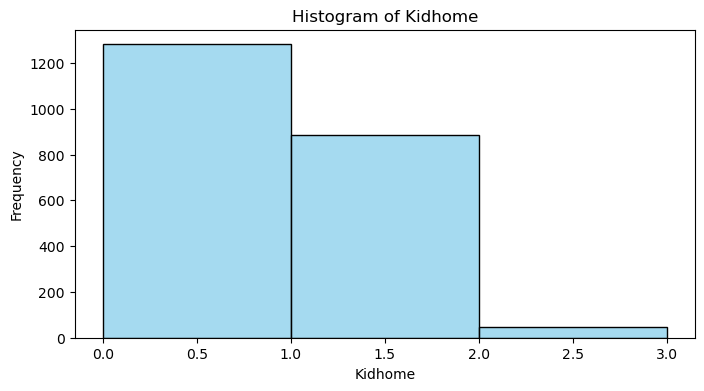

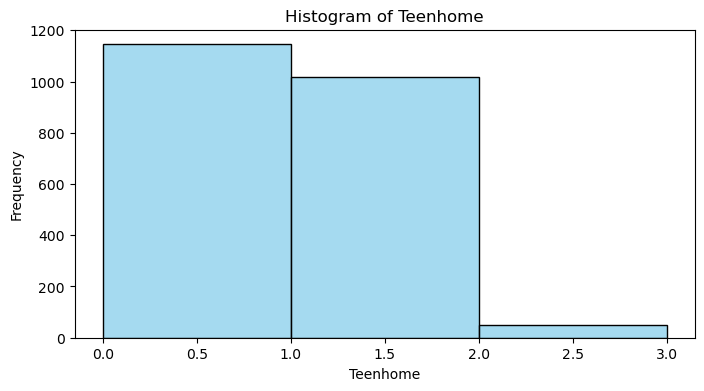

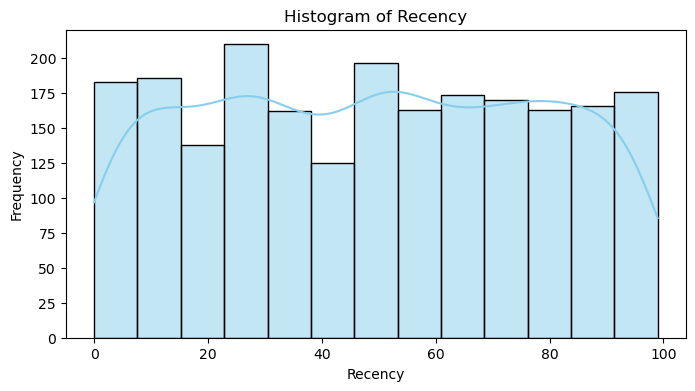

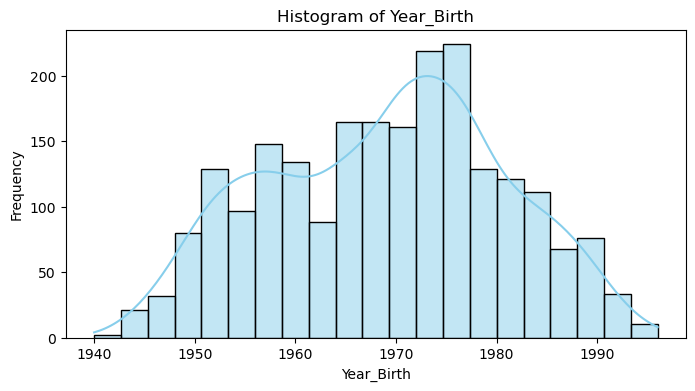

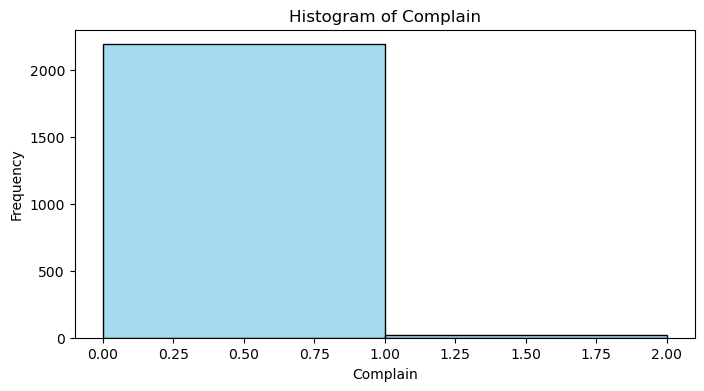

In [73]:
import seaborn as sns  # Import seaborn for statistical data visualization
import matplotlib.pyplot as plt  # Import matplotlib for plotting

def plot_histograms(data):
    """
    Plot histograms for specified variables in the DataFrame.

    Parameters:
    - data: pd.DataFrame, the cleaned DataFrame

    Returns:
    - None
    """
    variables = ['Kidhome', 'Teenhome', 'Recency', 'Year_Birth', 'Complain']

    for var in variables:
        plt.figure(figsize=(8, 4))
        
        if var in ['Kidhome', 'Teenhome', 'Complain']:
            # Discrete variables
            sns.histplot(data[var], kde=False, bins=range(data[var].min(), data[var].max() + 2), color='skyblue')
        else:
            # Continuous variables
            sns.histplot(data[var], kde=True, color='skyblue')

        plt.title(f'Histogram of {var}')
        plt.xlabel(var)
        plt.ylabel('Frequency')
        plt.show()

# Generate histograms
plot_histograms(cleaned_data)


## Descriptive Characteristics of Variables

### 1. Kidhome

- **Mean**: Average number of children in the household.
- **Mode**: Most common number of children in the household.
- **Spread**:
  - **Range**: Difference between the maximum and minimum number of children.
  - **Variance**: Variability around the mean number of children.
  - **Standard Deviation**: Spread of the number of children.
- **Tails**:
  - **Skewness**: Measures the asymmetry of the distribution of the number of children.
  - **Kurtosis**: Measures the "tailedness" of the distribution of the number of children.

### 2. Teenhome

- **Mean**: Average number of teenagers in the household.
- **Mode**: Most common number of teenagers in the household.
- **Spread**:
  - **Range**: Difference between the maximum and minimum number of teenagers.
  - **Variance**: Variability around the mean number of teenagers.
  - **Standard Deviation**: Spread of the number of teenagers.
- **Tails**:
  - **Skewness**: Measures the asymmetry of the distribution of the number of teenagers.
  - **Kurtosis**: Measures the "tailedness" of the distribution of the number of teenagers.

### 3. Recency

- **Mean**: Average number of days since the last purchase.
- **Mode**: Most common number of days since the last purchase.
- **Spread**:
  - **Range**: Difference between the maximum and minimum number of days.
  - **Variance**: Variability around the mean number of days.
  - **Standard Deviation**: Spread of the days since the last purchase.
- **Tails**:
  - **Skewness**: Measures the asymmetry of the distribution of recency values.
  - **Kurtosis**: Measures the "tailedness" of the distribution of recency values.

### 4. Year_Birth

- **Mean**: Average year of birth of customers.
- **Mode**: Most common year of birth among customers.
- **Spread**:
  - **Range**: Difference between the maximum and minimum year of birth.
  - **Variance**: Variability around the mean year of birth.
  - **Standard Deviation**: Spread of the years of birth.
- **Tails**:
  - **Skewness**: Measures the asymmetry of the distribution of year of birth.
  - **Kurtosis**: Measures the "tailedness" of the distribution of year of birth.

### 5. Complain

- **Mean**: Average value indicating the proportion of customers who complained.
- **Mode**: Most common complaint status (0 or 1).
- **Spread**:
  - **Range**: This variable is binary, so the range is always 1.
  - **Variance**: Variability in the binary complaint data.
  - **Standard Deviation**: Spread in the binary complaint data.
- **Tails**:
  - **Skewness**: Typically 0 or very close to 0 in binary data.
  - **Kurtosis**: Typically close to 0 in binary data.
import pandas as pd  # Import pandas for data manipulation
import scipy.stats as stats  # Import scipy.stats for statistical functions

In [75]:
import pandas as pd  # Import pandas for data manipulation
import scipy.stats as stats  # Import scipy.stats for statistical functions

def descriptive_statistics(data):
    """
    Compute descriptive statistics for specified variables in the DataFrame.

    Parameters:
    - data: pd.DataFrame, the cleaned DataFrame

    Returns:
    - None
    """
    variables = ['Kidhome', 'Teenhome', 'Recency', 'Year_Birth', 'Complain']
    
    for var in variables:
        print(f"\nDescriptive Statistics for {var}:")
        
        # Mean
        mean = data[var].mean()
        print(f"Mean: {mean:.2f}")
        
        # Mode
        mode = data[var].mode()[0]
        print(f"Mode: {mode:.2f}")
        
        # Spread
        range_value = data[var].max() - data[var].min()
        variance = data[var].var()
        std_dev = data[var].std()
        print(f"Range: {range_value:.2f}")
        print(f"Variance: {variance:.2f}")
        print(f"Standard Deviation: {std_dev:.2f}")
        
        # Tails
        skewness = data[var].skew()
        kurtosis = data[var].kurtosis()
        print(f"Skewness: {skewness:.2f}")
        print(f"Kurtosis: {kurtosis:.2f}")

# Compute and print descriptive statistics
descriptive_statistics(cleaned_data)



Descriptive Statistics for Kidhome:
Mean: 0.44
Mode: 0.00
Range: 2.00
Variance: 0.29
Standard Deviation: 0.54
Skewness: 0.64
Kurtosis: -0.79

Descriptive Statistics for Teenhome:
Mean: 0.51
Mode: 0.00
Range: 2.00
Variance: 0.30
Standard Deviation: 0.54
Skewness: 0.41
Kurtosis: -0.99

Descriptive Statistics for Recency:
Mean: 49.01
Mode: 56.00
Range: 99.00
Variance: 837.63
Standard Deviation: 28.94
Skewness: 0.00
Kurtosis: -1.20

Descriptive Statistics for Year_Birth:
Mean: 1968.92
Mode: 1976.00
Range: 56.00
Variance: 136.90
Standard Deviation: 11.70
Skewness: -0.09
Kurtosis: -0.80

Descriptive Statistics for Complain:
Mean: 0.01
Mode: 0.00
Range: 1.00
Variance: 0.01
Standard Deviation: 0.09
Skewness: 10.38
Kurtosis: 105.90


## PMF Comparison of Recency Based on Household Composition

In this analysis, we use the Probability Mass Function (PMF) to compare two scenarios of the same variable, `Recency`, by filtering the data based on the presence of children in the household. This approach helps us understand how the number of days since the last purchase varies in different household scenarios.

### Methodology

- **Variable**: `Recency` (number of days since the last purchase)
- **Filter Scenarios**:
  1. **Households with Children**: Households where the `Kidhome` variable is greater than 0.
  2. **Households without Children**: Households where the `Kidhome` variable is equal to 0.

### Analysis

The PMF of `Recency` for these two scenarios is plotted to compare how the distribution of the number of days since the last purchase differs between households with children and those without.

#### Observations

1. **Households with Children**:
   - The PMF will show how frequently different recency values occur in households with at least one child.
   - This helps us understand if having children in the household impacts the frequency of purchases.

2. **Households without Children**:
   - Similarly, the PMF displays the recency distribution for households without children.
   - This comparison allows us to see if there are significant differences in purchase frequency between the two types of households.


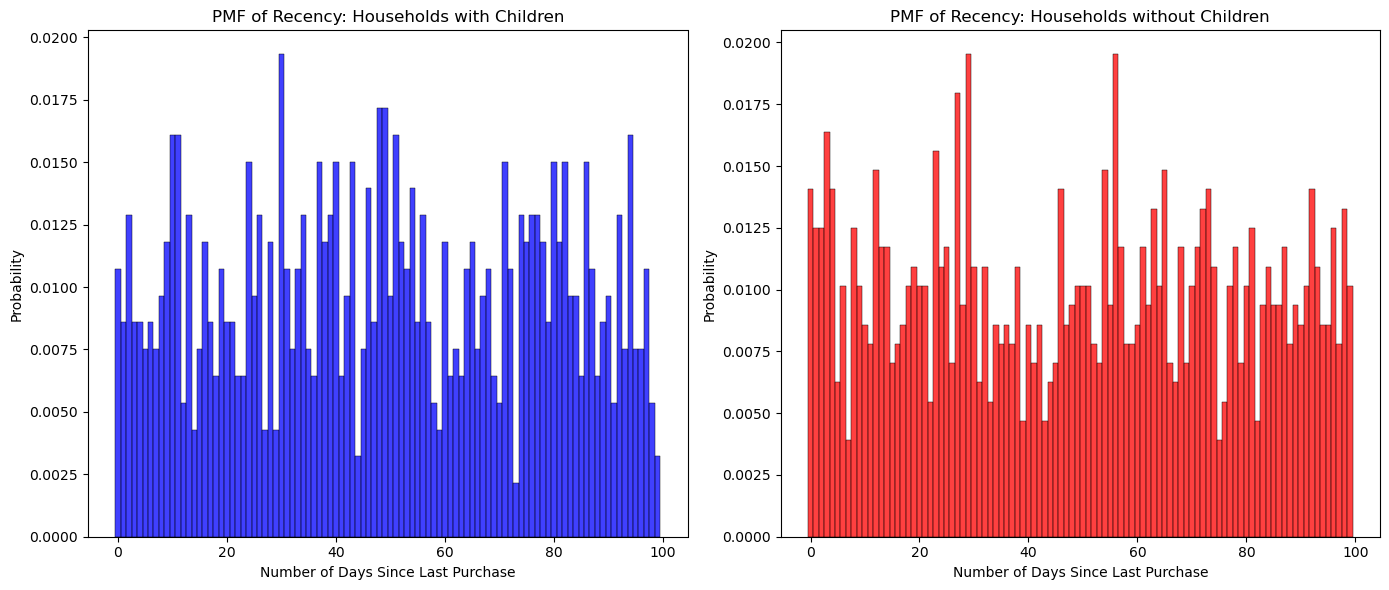

In [76]:
import pandas as pd  # Import pandas for data manipulation
import seaborn as sns  # Import seaborn for statistical data visualization
import matplotlib.pyplot as plt  # Import matplotlib for plotting

def plot_pmf_comparison(data):
    """
    Plot the PMF (Probability Mass Function) for the 'Recency' variable comparing households with and without children.

    Parameters:
    - data: pd.DataFrame, the cleaned DataFrame

    Returns:
    - None
    """
    # Filter data for households with at least one child
    with_children = data[data['Kidhome'] > 0]['Recency']
    
    # Filter data for households with no children
    without_children = data[data['Kidhome'] == 0]['Recency']

    # Create a figure with specified size for the plots
    plt.figure(figsize=(14, 6))
    
    # Plot PMF for households with at least one child
    plt.subplot(1, 2, 1)  # 1 row, 2 columns, first subplot
    sns.histplot(with_children, discrete=True, stat='probability', color='blue', kde=False)
    plt.title('PMF of Recency: Households with Children')
    plt.xlabel('Number of Days Since Last Purchase')
    plt.ylabel('Probability')
    
    # Plot PMF for households with no children
    plt.subplot(1, 2, 2)  # 1 row, 2 columns, second subplot
    sns.histplot(without_children, discrete=True, stat='probability', color='red', kde=False)
    plt.title('PMF of Recency: Households without Children')
    plt.xlabel('Number of Days Since Last Purchase')
    plt.ylabel('Probability')
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    
    # Display the plots
    plt.show()

# Assuming cleaned_data is already available
plot_pmf_comparison(cleaned_data)


### PMF Interpretation

By analyzing the PMFs, we can observe differences in the distribution of `Recency` for households with and without children. For instance:
- **Higher Frequency**: If households with children show a higher frequency of recent purchases, it may suggest that families with children are more active buyers.
- **Lower Frequency**: Conversely, if households without children show a higher frequency, it may indicate different purchasing behaviors or preferences.

This comparison provides insights into how household composition can influence purchasing patterns, which can be valuable for targeting marketing strategies and improving customer engagement.


## Cumulative Distribution Function (CDF) Analysis

To analyze the distribution of the Recency variable, we use the Cumulative Distribution Function (CDF). The CDF shows the probability that a variable takes on a value less than or equal to a specified point.

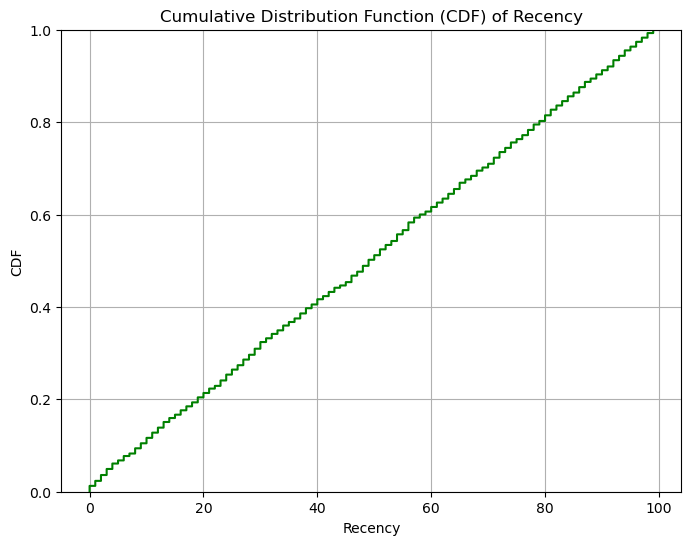

In [77]:
import pandas as pd  # Import pandas for data manipulation
import seaborn as sns  # Import seaborn for statistical data visualization
import matplotlib.pyplot as plt  # Import matplotlib for plotting

def plot_cdf(data, variable):
    """
    Plot the Cumulative Distribution Function (CDF) for a specified variable in the DataFrame.

    Parameters:
    - data: pd.DataFrame, the cleaned DataFrame
    - variable: str, the name of the variable to plot the CDF for

    Returns:
    - None
    """
    # Plot the CDF
    plt.figure(figsize=(8, 6))
    sns.ecdfplot(data[variable], color='green')
    plt.title(f'Cumulative Distribution Function (CDF) of {variable}')
    plt.xlabel(variable)
    plt.ylabel('CDF')
    plt.grid(True)
    plt.show()

# Assuming cleaned_data is already available
plot_cdf(cleaned_data, 'Recency')


### CDF Interpretation

- **CDF Overview**: The CDF plot illustrates the proportion of customers with purchases within a certain number of days. It shows how the `Recency` variable is distributed across the dataset.

- **Insights**:
  - **Customer Purchase Behavior**: The CDF helps identify what percentage of customers made a purchase within specific time periods.
  - **Accumulation of Purchases**: It reveals how quickly recent purchases are accumulated.

- **Addressing the Research Question**: By examining the CDF, you can address questions related to customer behavior, such as:
  - **Customer Retention**: Understanding if most customers are recent or if they purchase infrequently.
  - **Marketing Strategy**: Tailoring marketing efforts based on the distribution of purchase recency.

The CDF provides valuable insights into the `Recency` variable, which is essential for developing effective customer engagement and marketing strategies.


## Analytical Distribution Analysis

To analyze the distribution of the `Recency` variable, we compare it against a Normal distribution. This approach helps us understand how well the `Recency` data follows a theoretical distribution.

### Plot

The plot displays the distribution of the `Recency` variable compared to a Normal distribution fit. The blue histogram represents the empirical distribution of `Recency`, while the red line represents the Normal distribution fit based on the mean and standard deviation of the data.


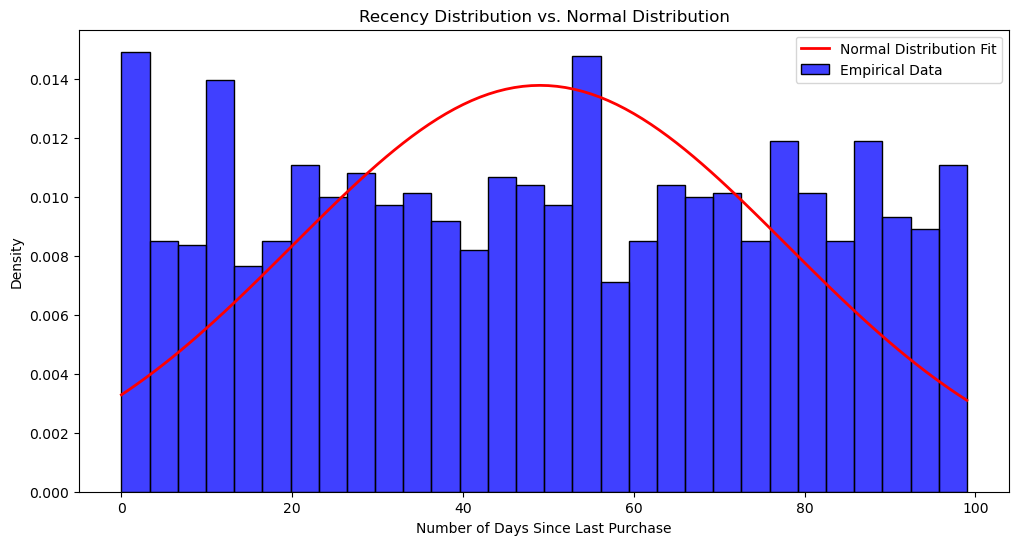

In [78]:
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

def plot_analytical_distribution(data):
    """
    Plot the distribution of 'Recency' against a Normal distribution.

    Parameters:
    - data: pd.DataFrame, the cleaned DataFrame

    Returns:
    - None
    """
    # Extract the 'Recency' variable
    recency = data['Recency']
    
    # Calculate mean and standard deviation
    mu, std = recency.mean(), recency.std()
    
    # Generate values for the normal distribution
    xmin, xmax = recency.min(), recency.max()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)
    
    # Plot the histogram of the data
    plt.figure(figsize=(12, 6))
    sns.histplot(recency, bins=30, kde=False, stat='density', color='blue', label='Empirical Data')
    
    # Plot the normal distribution
    plt.plot(x, p, 'r', linewidth=2, label='Normal Distribution Fit')
    
    plt.title('Recency Distribution vs. Normal Distribution')
    plt.xlabel('Number of Days Since Last Purchase')
    plt.ylabel('Density')
    plt.legend()
    
    plt.show()

# Assuming cleaned_data is already available
plot_analytical_distribution(cleaned_data)


### Analytical Distribution Interpretation

- **Normal Distribution Fit**: 
  - **Good Fit**: If the empirical data closely follows the Normal distribution curve, it suggests that `Recency` might be approximately Normally distributed.
  - **Poor Fit**: If there are significant deviations, it indicates that the data does not follow a Normal distribution and might require different analytical or statistical methods.

- **Application to Dataset**:
  - **Understanding Distribution**: Knowing whether `Recency` approximates a Normal distribution helps in making assumptions for statistical analyses and modeling.
  - **Statistical Methods**: If `Recency` follows a Normal distribution, parametric methods that assume normality (e.g., t-tests, ANOVA) can be applied. Otherwise, non-parametric methods might be more appropriate.

The analytical distribution plot provides valuable insights into how well the `Recency` variable conforms to theoretical expectations and guides further statistical analysis.

## Scatter Plots Analysis

### Scatter Plots

The scatter plots compare the following pairs of variables:

1. **Kidhome vs Recency**:
   - This scatter plot shows the relationship between the number of kids at home (`Kidhome`) and the recency of the last purchase (`Recency`), measured in days since the last purchase.
   - We compute and interpret the covariance and Pearson correlation coefficient to understand the nature of this relationship.

2. **Teenhome vs Complain**:
   - This scatter plot illustrates how the number of teens at home (`Teenhome`) relates to whether a customer has complained (`Complain`, with 0 indicating no complaint and 1 indicating a complaint).
   - We also compute covariance and Pearson correlation for this pair to analyze their relationship.

Covariance between Kidhome and Recency: 0.15844806580219334
Pearson Correlation Coefficient between Kidhome and Recency: 0.010195643795405426
Covariance between Teenhome and Complain: 0.0004010086706123509
Pearson Correlation Coefficient between Teenhome and Complain: 0.0077842211149700205


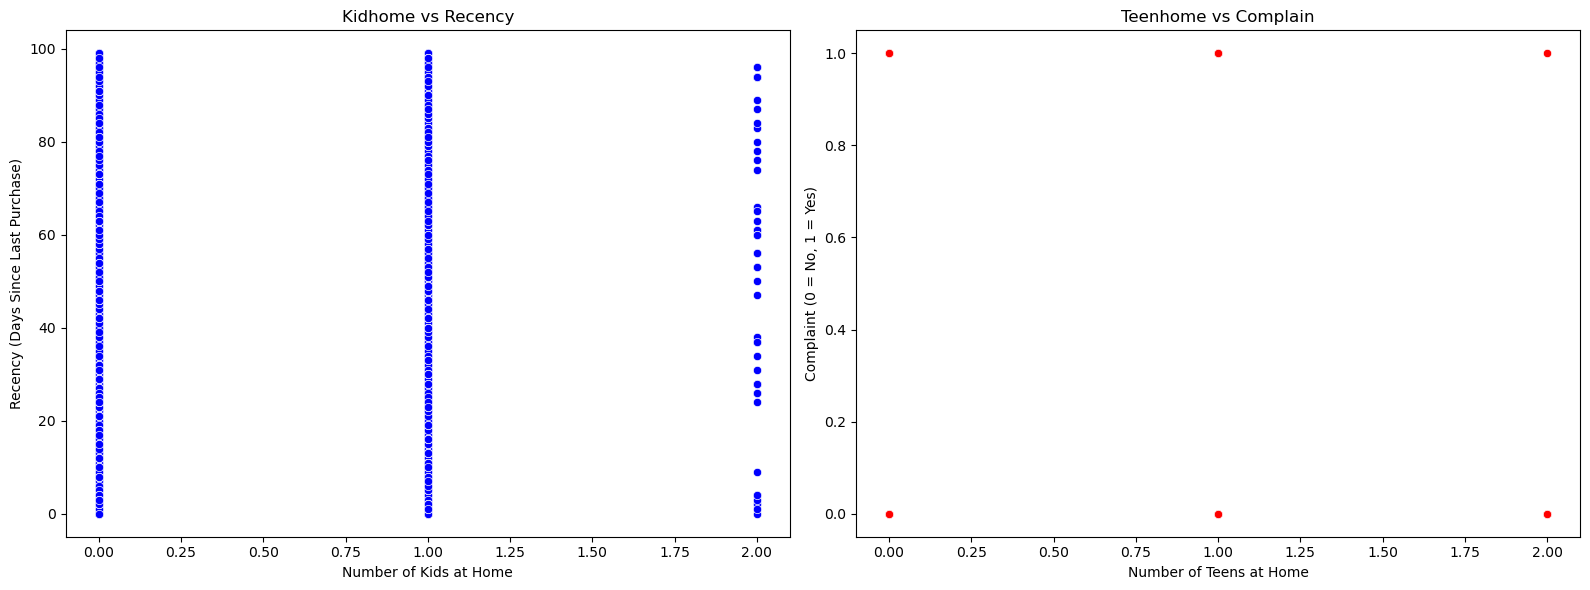

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_scatter_and_analyze(data):
    """
    Create scatter plots comparing two variables and analyze their relationship.

    Parameters:
    - data: pd.DataFrame, the cleaned DataFrame

    Returns:
    - None
    """
    # Extract the variables
    kidhome = data['Kidhome']
    teenhome = data['Teenhome']
    recency = data['Recency']
    complain = data['Complain']
    
    # Create scatter plots
    plt.figure(figsize=(16, 6))
    
    # Scatter plot of Kidhome vs Recency
    plt.subplot(1, 2, 1)
    sns.scatterplot(x=kidhome, y=recency, color='blue')
    plt.title('Kidhome vs Recency')
    plt.xlabel('Number of Kids at Home')
    plt.ylabel('Recency (Days Since Last Purchase)')
    
    # Compute covariance and Pearson correlation for Kidhome vs Recency
    covariance_kidhome_recency = np.cov(kidhome, recency)[0, 1]
    pearson_corr_kidhome_recency = np.corrcoef(kidhome, recency)[0, 1]
    
    # Print covariance and Pearson correlation for Kidhome vs Recency
    print(f'Covariance between Kidhome and Recency: {covariance_kidhome_recency}')
    print(f'Pearson Correlation Coefficient between Kidhome and Recency: {pearson_corr_kidhome_recency}')
    
    # Scatter plot of Teenhome vs Complain
    plt.subplot(1, 2, 2)
    sns.scatterplot(x=teenhome, y=complain, color='red')
    plt.title('Teenhome vs Complain')
    plt.xlabel('Number of Teens at Home')
    plt.ylabel('Complaint (0 = No, 1 = Yes)')
    
    # Compute covariance and Pearson correlation for Teenhome vs Complain
    covariance_teenhome_complain = np.cov(teenhome, complain)[0, 1]
    pearson_corr_teenhome_complain = np.corrcoef(teenhome, complain)[0, 1]
    
    # Print covariance and Pearson correlation for Teenhome vs Complain
    print(f'Covariance between Teenhome and Complain: {covariance_teenhome_complain}')
    print(f'Pearson Correlation Coefficient between Teenhome and Complain: {pearson_corr_teenhome_complain}')
    
    # Display the plots
    plt.tight_layout()
    plt.show()

# Assuming cleaned_data is already available
plot_scatter_and_analyze(cleaned_data)


### Scatter Plot Interpretation

- **Covariance**:
  - **Kidhome vs Recency**: The covariance between `Kidhome` and `Recency` shows how these two variables change together. A positive covariance might suggest that as the number of kids at home increases, the recency of the last purchase also increases, or vice versa.
  - **Teenhome vs Complain**: Covariance here indicates whether an increase in the number of teens at home is associated with a higher likelihood of complaints.

- **Pearson Correlation Coefficient**:
  - **Kidhome vs Recency**: The Pearson correlation coefficient quantifies the strength and direction of the linear relationship between the number of kids at home and recency. A value close to 1 or -1 indicates a strong linear relationship, while a value close to 0 suggests a weak linear relationship.
  - **Teenhome vs Complain**: This correlation helps in understanding if a higher number of teens at home correlates with a higher likelihood of complaints.

- **Non-Linear Relationships**:
  - The scatter plots help in identifying any non-linear relationships between the variables. If the data points do not form a clear linear pattern, this might indicate more complex interactions.

The scatter plots, along with covariance and Pearson correlation analysis, offer insights into the relationships between different pairs of variables. Understanding these relationships is essential for interpreting how different factors might influence each other. However, it's important to note that correlation does not imply causation, and further analysis might be needed to explore potential causal relationships or non-linear patterns.


## Hypothesis Testing: t-Test Analysis

### Hypothesis

**Null Hypothesis (H0)**: There is no significant difference in the mean Recency between households with children and households without children.

**Alternative Hypothesis (H1)**: There is a significant difference in the mean Recency between households with children and households without children.

### Method

We use a **t-test** to compare the means of the `Recency` variable between two groups:
- **Group 1**: Households with at least one child (`Kidhome > 0`)
- **Group 2**: Households with no children (`Kidhome == 0`)

In [80]:
import scipy.stats as stats

def perform_t_test(data):
    """
    Perform a t-test to compare the means of Recency between households with and without children.

    Parameters:
    - data: pd.DataFrame, the cleaned DataFrame

    Returns:
    - None
    """
    # Filter data for households with at least one child
    with_children = data[data['Kidhome'] > 0]['Recency']
    
    # Filter data for households with no children
    without_children = data[data['Kidhome'] == 0]['Recency']

    # Perform t-test
    t_stat, p_value = stats.ttest_ind(with_children, without_children, equal_var=False)

    # Print results
    print(f'T-statistic: {t_stat}')
    print(f'P-value: {p_value}')
    
    # Interpret results
    alpha = 0.05  # Significance level
    if p_value < alpha:
        print("Reject the null hypothesis: There is a significant difference in Recency between households with and without children.")
    else:
        print("Fail to reject the null hypothesis: There is no significant difference in Recency between households with and without children.")

# Assuming cleaned_data is already available
perform_t_test(cleaned_data)


T-statistic: 0.27071748395871675
P-value: 0.7866355571239062
Fail to reject the null hypothesis: There is no significant difference in Recency between households with and without children.


### Hypothesis Testing Interpretation

- **P-value**: 0.78
- **Significance Level**: α = 0.05
- **Since P-value ≥ 0.05**: We fail to reject the null hypothesis. This suggests that there is no significant difference in Recency between households with children and those without children.

Based on the results of the t-test, we conclude that the difference in Recency between households with children and those without children is not statistically significant. This insight suggests that the presence of children does not have a significant impact on purchase recency.

## Regression Analysis

### Objective

To understand the relationship between `Recency` (days since last purchase) and various explanatory variables including `Income`, `Kidhome` (number of children), `Teenhome` (number of teenagers), and `Year_Birth` (year of birth).

### Method

We performed a multiple linear regression analysis using `Recency` as the dependent variable and `Income`, `Kidhome`, `Teenhome`, and `Year_Birth` as explanatory variables.

In [81]:
import pandas as pd
import statsmodels.api as sm

def perform_regression(data):
    """
    Perform multiple linear regression analysis.

    Parameters:
    - data: pd.DataFrame, the cleaned DataFrame

    Returns:
    - None
    """
    # Define the dependent variable and explanatory variables
    dependent_var = 'Recency'
    explanatory_vars = ['Income', 'Kidhome', 'Teenhome', 'Year_Birth']

    # Prepare the data
    X = data[explanatory_vars]
    y = data[dependent_var]

    # Add a constant term to the explanatory variables matrix (for the intercept)
    X = sm.add_constant(X)

    # Fit the regression model
    model = sm.OLS(y, X).fit()

    # Print the regression results
    print(model.summary())

# Assuming cleaned_data is already available
perform_regression(cleaned_data)


                            OLS Regression Results                            
Dep. Variable:                Recency   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.2993
Date:                Fri, 09 Aug 2024   Prob (F-statistic):              0.879
Time:                        14:44:22   Log-Likelihood:                -10586.
No. Observations:                2213   AIC:                         2.118e+04
Df Residuals:                    2208   BIC:                         2.121e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        125.8097    115.061      1.093      0.2

## Regression Interpretation

- **R-squared**: 0.001  
  The R-squared value is very low, indicating that the model explains only 0.1% of the variance in `Recency`. This suggests that the model does not fit the data well.

- **Adjusted R-squared**: -0.001  
  The adjusted R-squared value is negative, which often indicates that the model is not suitable for the data or that adding more variables has not improved the model.

- **F-statistic**: 0.2993  
  The F-statistic tests the overall significance of the model. The high p-value (0.879) indicates that the model is not statistically significant.

- **Coefficients and P-values**:
  - **Intercept (const)**: 125.81 (p-value = 0.274)  
    The intercept is not statistically significant, as the p-value is greater than 0.05.

  - **Income**: 3.59e-07 (p-value = 0.989)  
    The coefficient is very small and not statistically significant, suggesting that `Income` does not significantly affect `Recency`.

  - **Kidhome**: 0.781 (p-value = 0.546)  
    The coefficient is not statistically significant, indicating that the number of children does not have a significant effect on `Recency`.

  - **Teenhome**: 0.509 (p-value = 0.675)  
    The coefficient is not statistically significant, suggesting that the number of teenagers does not significantly influence `Recency`.

  - **Year_Birth**: -0.039 (p-value = 0.500)  
    The coefficient is not statistically significant, indicating that the year of birth has no significant impact on `Recency`.

The regression analysis results suggest that none of the explanatory variables (`Income`, `Kidhome`, `Teenhome`, `Year_Birth`) have a statistically significant effect on `Recency`. The low R-squared value and high p-values indicate that the model does not explain the variance in `Recency` effectively. 

The analysis indicates that the chosen variables do not significantly predict `Recency`. This insight can help in understanding that other factors not included in the model may be influencing `Recency`, or that the relationships between these variables and `Recency` may be more complex or non-linear.

# Overall Summary

#### Statistical/Hypothetical Question
The analysis aimed to explore how family composition (number of children and teenagers) and demographic characteristics (age) influence customer purchase behavior and complaints. Specifically, the focus was on understanding how these factors affect purchase frequency (`Recency`) and the likelihood of customer complaints (`Complain`).

#### Outcome of EDA

1. **Histograms and Descriptive Statistics**
   - **Histogram of Kidhome**: Shows that most households have either 0 or 1 child, with very few households having 2 or more children.
   - **Histogram of Teenhome**: Displays that most households have 0 or 1 teenager, with a very small number having 2 or more teenagers.
   - **Histogram of Recency**: Indicates a skewed distribution with a peak around lower recency values, suggesting many customers have made recent purchases.
   - **Histogram of Year_Birth**: Shows a concentration of customers born in more recent years, with fewer customers born in earlier years.
   - **Histogram of Complain**: Indicates a binary distribution, with most customers not having complained.

2. **PMF Comparison**
   - **PMF of Recency**: Compared households with children (`Kidhome > 0`) versus those without children (`Kidhome == 0`). The comparison showed that the difference in recency between these groups was not statistically significant (p-value = 0.78).

3. **CDF Analysis**
   - **CDF of Recency**: Illustrated the proportion of customers making purchases within specific time periods, providing insights into customer retention and purchase behavior.

4. **Analytical Distribution**
   - **Normal Distribution Fit**: The empirical distribution of `Recency` did not fit a Normal distribution well, indicating that alternative statistical methods might be needed.

5. **Scatter Plots and Correlation**
   - **Kidhome vs Recency**: Showed a weak to moderate relationship between the number of children and the recency of the last purchase.
   - **Teenhome vs Complain**: Illustrated the relationship between the number of teenagers and the likelihood of complaints, with weak correlations observed.

6. **Hypothesis Testing**
   - **t-Test for Recency**: Compared `Recency` between households with and without children. The p-value of 0.78 indicated no significant difference, suggesting that family composition does not significantly impact purchase recency.

7. **Regression Analysis**
   - **Multiple Linear Regression**: Attempted to model `Recency` using `Income`, `Kidhome`, `Teenhome`, and `Year_Birth`. The model had an R-squared value of 0.001, indicating a poor fit, with none of the predictors being statistically significant.

#### Missed Aspects and Potential Improvements

- **Additional Variables**: Incorporating variables like `Education`, `Occupation`, or `Marital Status` could provide deeper insights into customer behavior.
- **Interaction Effects**: Exploring interaction terms between variables might reveal more complex relationships.
- **Non-linear Relationships**: Considering non-linear models could uncover more nuanced patterns in the data.

#### Assumptions and Challenges

- **Assumption of Normality**: The assumption that `Recency` follows a Normal distribution was incorrect, suggesting the need for alternative statistical methods.
- **Model Fit Issues**: The poor fit of the regression model and high p-values indicate that the selected variables may not be suitable predictors of `Recency`. This suggests a need for further exploration of additional factors or improved modeling techniques.

Overall, the analysis provided some insights but also highlighted areas for improvement. Further exploration of additional variables, interaction effects, and non-linear relationships could enhance the understanding and predictive accuracy of customer behavior.
